# ASPR
*Administration for Strategic Planning & Preparedness*

## Test to Treat
While vaccines remain the most effective way to prevent COVID-19 infection, there are also treatments available for people who are infected with the disease. These treatments may help individuals avoid severe illness, hospitalization, and death.

In [77]:
import pandas as pd
import matplotlib
from pandas import DataFrame
import matplotlib.pyplot as plt

In [78]:
aspr = pd.read_csv("ASPR_Treatments_Locator_20250104.csv", low_memory=False)

In [79]:
# Display the size and data types
aspr_shape = aspr.shape
print(f' The dataframe has {aspr_shape}[0] rows and {aspr_shape}[1] columns')

print(aspr.info())

 The dataframe has (881488, 34)[0] rows and (881488, 34)[1] columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 881488 entries, 0 to 881487
Data columns (total 34 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Provider Name                   881488 non-null  object 
 1   Address 1                       881488 non-null  object 
 2   Address 2                       111289 non-null  object 
 3   City                            881488 non-null  object 
 4   State                           881488 non-null  object 
 5   Zip                             881488 non-null  object 
 6   Public Phone                    245389 non-null  object 
 7   Latitude                        881488 non-null  float64
 8   Longitude                       881488 non-null  float64
 9   Geopoint                        881488 non-null  object 
 10  Last Report Date                881485 non-null  object 
 11  Is PAP Sit

In [80]:
# Check the first few lines

aspr.head()

,Provider Name,Address 1,Address 2,City,State,Zip,Public Phone,Latitude,Longitude,Geopoint,...,Has Veklury,Has Oseltamivir Generic,Has Oseltamivir Suspension,Has Oseltamivir Tamiflu,Has Baloxavir,Has Zanamivir,Has Peramivir,Grantee Code,Is Flu,Is COVID-19
0,CVS PHARMACY #05246,110 HWY 98,NaN,PORT SAINT JOE,FL,32456,NaN,30.016430,-85.430510,POINT (-85.43051 30.01643),...,False,False,False,False,False,False,False,CV1,False,True
1,PUBLIX PHARMACY #0567,2517 SOUTH FEDERAL HIGHWAY,NaN,FT PIERCE,FL,34982,NaN,27.319630,-80.316317,POINT (-80.316317 27.31963),...,False,False,False,False,False,False,False,PX1,False,True
2,WALGREENS #4379,4320 26TH ST W,NaN,BRADENTON,FL,34205-3563,NaN,27.462954,-82.588373,POINT (-82.588373 27.462954),...,False,False,False,False,False,False,False,WG1,False,True
3,PUBLIX PHARMACY #0894,6820 OKEECHOBEE BLVD,NaN,WEST PALM BEACH,FL,33411,NaN,26.705894,-80.150789,POINT (-80.150789 26.705894),...,False,False,False,False,False,False,False,PX1,False,True
4,PUBLIX PHARMACY #0019,731 DUVAL STATION RD SUITE 4,NaN,JACKSONVILLE,FL,32218,NaN,30.485316,-81.604614,POINT (-81.604614 30.485316),...,False,False,False,False,False,False,False,PX1,False,True


In [81]:
# Check the last few lines

aspr.tail()

,Provider Name,Address 1,Address 2,City,State,Zip,Public Phone,Latitude,Longitude,Geopoint,...,Has Veklury,Has Oseltamivir Generic,Has Oseltamivir Suspension,Has Oseltamivir Tamiflu,Has Baloxavir,Has Zanamivir,Has Peramivir,Grantee Code,Is Flu,Is COVID-19
881483,PILL PLUS PHARMACY,4215 CONNECTICUT AVE NW # ST1,NaN,WASHINGTON,DC,20008-1159,NaN,38.943706,-77.062826,POINT (-77.062826 38.943706),...,False,False,False,False,False,False,False,NaN,False,True
881484,HEALING TOUCH PHARMACY 03,3415 23RD ST SE,NaN,WASHINGTON,DC,20020-1921,NaN,38.847577,-76.971292,POINT (-76.971292 38.847577),...,False,False,False,False,False,False,False,NaN,False,True
881485,AVITA PHARMACY 1071,600 PENNSYLVANIA AVE SE,LOWER LEVEL A,WASHINGTON,DC,20003-4316,NaN,38.885207,-76.998125,POINT (-76.998125 38.885207),...,False,False,False,False,False,False,False,NaN,False,True
881486,AHF PHARMACY,650 PENNSYLVANIA AVE SE,STE 380,WASHINGTON,DC,25601,NaN,38.885410,-76.997035,POINT (-76.997035 38.88541),...,False,False,False,False,False,False,False,NaN,False,True
881487,Canyonlands HC - Duncan Pharmacy,103 Fairgrounds Rd,NaN,Duncan,AZ,85534,928-645-9675,32.726224,-109.098057,POINT (-109.098057 32.726224),...,False,False,False,False,False,False,False,HR2,False,True


In [82]:
# Checking for nulls
print(aspr.isnull().any().any())
aspr.isnull().sum()

True


Provider Name                          0
Address 1                              0
Address 2                         770199
City                                   0
State                                  0
Zip                                    0
Public Phone                      636099
Latitude                               0
Longitude                              0
Geopoint                               0
Last Report Date                       3
Is PAP Site                            0
Prescribing Services Available    866018
Appointment URL                   874429
Home Delivery                          0
Is ICATT Site                          0
Has USG Product                        0
Has Commercial Product                 0
Has Paxlovid                           0
Has Commercial Paxlovid                0
Has USG Paxlovid                       0
Has Lagevrio                           0
Has Commercial Lagevrio                0
Has USG Lagevrio                       0
Has Veklury     

In [83]:
# Remove columns
cols_to_drop = ['Address 1', 'Address 2', 'Latitude', 'Longitude', 'Geopoint', 'Public Phone', 'Prescribing Services Available', 'Appointment URL', 'Grantee Code']

aspr = aspr.drop(columns= cols_to_drop)

aspr.head()

,Provider Name,City,State,Zip,Last Report Date,Is PAP Site,Home Delivery,Is ICATT Site,Has USG Product,Has Commercial Product,...,Has USG Lagevrio,Has Veklury,Has Oseltamivir Generic,Has Oseltamivir Suspension,Has Oseltamivir Tamiflu,Has Baloxavir,Has Zanamivir,Has Peramivir,Is Flu,Is COVID-19
0,CVS PHARMACY #05246,PORT SAINT JOE,FL,32456,12/06/2024 12:00:00 AM,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,PUBLIX PHARMACY #0567,FT PIERCE,FL,34982,12/06/2024 12:00:00 AM,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,WALGREENS #4379,BRADENTON,FL,34205-3563,12/06/2024 12:00:00 AM,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,PUBLIX PHARMACY #0894,WEST PALM BEACH,FL,33411,12/06/2024 12:00:00 AM,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,PUBLIX PHARMACY #0019,JACKSONVILLE,FL,32218,12/06/2024 12:00:00 AM,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [84]:
# Dropping null
aspr_clean = aspr.dropna()

In [85]:
# checking null
print(aspr_clean.isnull().any().any())

False


In [86]:
#filtered_data = kick_starter[kick_starter['State'] == 'successful']

# Group by Category and State and sum the specified columns
#top_ten_cats = filtered_data.groupby(['Category', 'State'])[['Backers', 'Usd Pledged Real']].sum().reset_index()

# Sort the entire DataFrame by 'Usd Pledged Real' in descending order
#top_ten_cats = top_ten_cats.sort_values(by='Usd Pledged Real', ascending=False)

#top_ten_cats.head()

In [87]:
# changing clean back to aspr
aspr_clean = aspr

In [88]:
aspr.columns

Index(['Provider Name', 'City', 'State', 'Zip', 'Last Report Date',
       'Is PAP Site', 'Home Delivery', 'Is ICATT Site', 'Has USG Product',
       'Has Commercial Product', 'Has Paxlovid', 'Has Commercial Paxlovid',
       'Has USG Paxlovid', 'Has Lagevrio', 'Has Commercial Lagevrio',
       'Has USG Lagevrio', 'Has Veklury', 'Has Oseltamivir Generic',
       'Has Oseltamivir Suspension', 'Has Oseltamivir Tamiflu',
       'Has Baloxavir', 'Has Zanamivir', 'Has Peramivir', 'Is Flu',
       'Is COVID-19'],
      dtype='object')

In [93]:
# Filter for True in columns
aspr_grouped = aspr.groupby(['Has USG Product',
       'Has Commercial Product', 'Has Paxlovid', 'Has Commercial Paxlovid',
       'Has USG Paxlovid', 'Has Lagevrio', 'Has Commercial Lagevrio',
       'Has USG Lagevrio', 'Has Veklury', 'Has Oseltamivir Generic',
       'Has Oseltamivir Suspension', 'Has Oseltamivir Tamiflu',
       'Has Baloxavir', 'Has Zanamivir', 'Has Peramivir','Is Flu',
       'Is COVID-19'])

# Perform an aggregation (e.g., count occurrences of each group)
aggregated_data = aspr_grouped.size().reset_index(name='count')

# Now, you can sort the aggregated data by 'is Flu' and 'is COVID-19' columns
# Assuming you have the 'is Flu' and 'is COVID-19' columns in the aggregated data
sorted_data = aggregated_data.sort_values(by=['Is Flu', 'Is COVID-19'], ascending=[False, True])

# Display the result
print(sorted_data)

    Has USG Product  Has Commercial Product  Has Paxlovid  \
2             False                    True         False   
3             False                    True         False   
4             False                    True         False   
6             False                    True         False   
7             False                    True         False   
..              ...                     ...           ...   
74             True                    True          True   
75             True                    True          True   
76             True                    True          True   
77             True                    True          True   
85             True                    True          True   

    Has Commercial Paxlovid  Has USG Paxlovid  Has Lagevrio  \
2                     False             False         False   
3                     False             False         False   
4                     False             False         False   
6              

In [97]:
sorted_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 92 entries, 2 to 85
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Has USG Product             92 non-null     bool 
 1   Has Commercial Product      92 non-null     bool 
 2   Has Paxlovid                92 non-null     bool 
 3   Has Commercial Paxlovid     92 non-null     bool 
 4   Has USG Paxlovid            92 non-null     bool 
 5   Has Lagevrio                92 non-null     bool 
 6   Has Commercial Lagevrio     92 non-null     bool 
 7   Has USG Lagevrio            92 non-null     bool 
 8   Has Veklury                 92 non-null     bool 
 9   Has Oseltamivir Generic     92 non-null     bool 
 10  Has Oseltamivir Suspension  92 non-null     bool 
 11  Has Oseltamivir Tamiflu     92 non-null     bool 
 12  Has Baloxavir               92 non-null     bool 
 13  Has Zanamivir               92 non-null     bool 
 14  Has Peramivir    

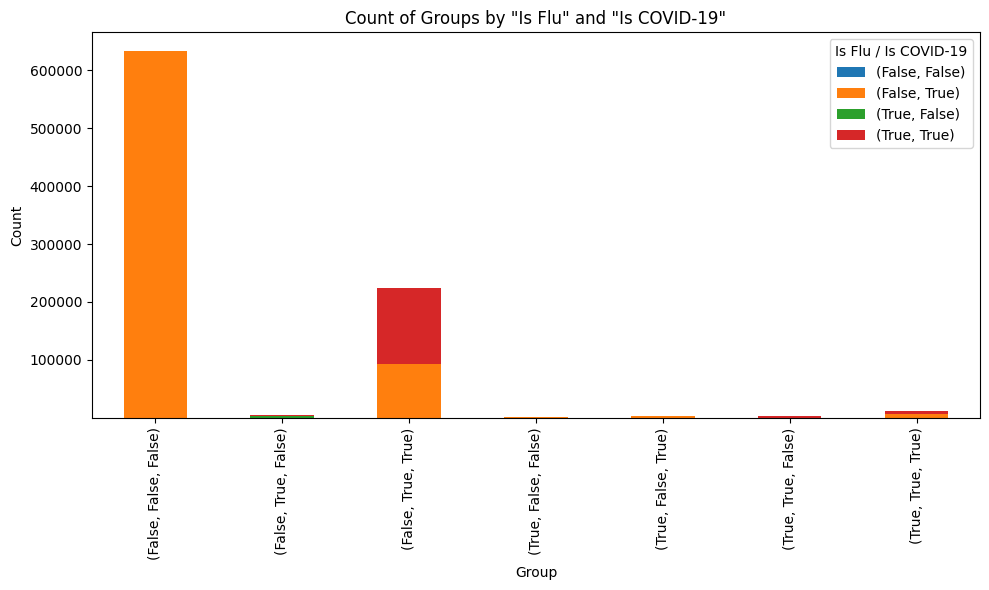

In [102]:
# Now, let's plot the sorted data.

# Example: Plotting a stacked bar chart to visualize the counts of 'Is Flu' and 'Is COVID-19'
# Pivot the data to make it suitable for stacked bar chart plotting
pivot_data = sorted_data.pivot_table(
    index=['Has USG Product', 'Has Commercial Product', 'Has Paxlovid'],  # Choose the relevant index
    columns=['Is Flu', 'Is COVID-19'],  # Plot categories based on these columns
    values='count',  # We want to visualize the counts
    aggfunc='sum',  # If there are multiple entries, sum them
    fill_value=0  # Fill missing values with 0
)

# Plotting a stacked bar chart
ax = pivot_data.plot(kind='bar', stacked=True, figsize=(10, 6))

# Add labels and title
plt.xlabel('Group')
plt.ylabel('Count')
plt.title('Count of Groups by "Is Flu" and "Is COVID-19"')
plt.legend(title='Is Flu / Is COVID-19')

# Display the plot
plt.tight_layout()  # Adjust layout for better spacing
plt.show()

In [108]:
sorted_data.columns

Index(['Has USG Product', 'Has Commercial Product', 'Has Paxlovid',
       'Has Commercial Paxlovid', 'Has USG Paxlovid', 'Has Lagevrio',
       'Has Commercial Lagevrio', 'Has USG Lagevrio', 'Has Veklury',
       'Has Oseltamivir Generic', 'Has Oseltamivir Suspension',
       'Has Oseltamivir Tamiflu', 'Has Baloxavir', 'Has Zanamivir',
       'Has Peramivir', 'Is Flu', 'Is COVID-19', 'count'],
      dtype='object')

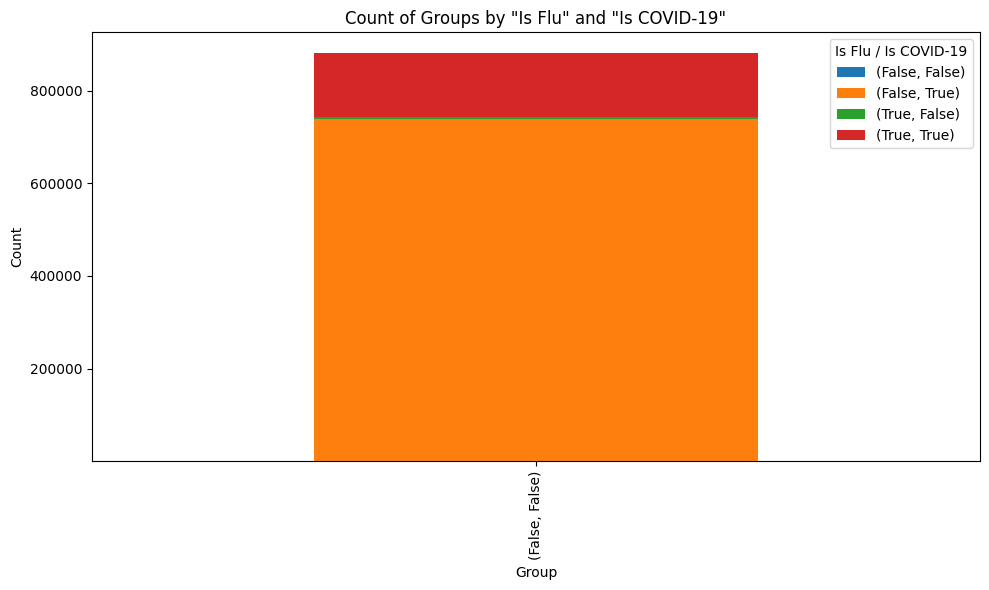

In [114]:


# Creating a function
def plot_aspr():
    # Ask the user to enter column names for 'cols_to_review'
    user_input = input("Please enter one or more column names, separated by commas (e.g., 'Has USG Product, Has Commercial Product'): ")
    
    # Split the input string into a list and strip any extra spaces
    cols_to_review = [col.strip() for col in user_input.split(',')]
    
    # Check if the DataFrame is not empty
    if not sorted_data.empty:
        # Pivot the data to make it suitable for plotting
        try:
            pivot_data = sorted_data.pivot_table(
                index=cols_to_review,  # Pass as a list directly
                columns=['Is Flu', 'Is COVID-19'],  # Plot categories based on these columns
                values='count',  # We want to visualize the counts
                aggfunc='sum',  # Sum if there are multiple entries
                fill_value=0  # Fill missing values with 0
            )

            # Plotting a stacked bar chart
            ax = pivot_data.plot(kind='bar', stacked=True, figsize=(10, 6))

            # Add labels and title
            plt.xlabel('Group')
            plt.ylabel('Count')
            plt.title('Count of Groups by "Is Flu" and "Is COVID-19"')
            plt.legend(title='Is Flu / Is COVID-19')

            # Display the plot
            plt.tight_layout()  # Adjust layout for better spacing
            plt.show()
        except Exception as e:
            print(f"Error while plotting: {e}")
    else:
        print("The DataFrame is empty. Please check your data.")

# Call the function to plot
plot_aspr()
